flow : CSV → Pandas → SQL Database → SQL Queries → Python Visualization

## Import Required Libraries

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

## Load data file

In [28]:
df = pd.read_csv('SuperStoreOrders.csv')

## explore data 

In [29]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [31]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

convert date columns

In [32]:
df['order_date']=pd.to_datetime(df['order_date'], format="mixed")
df['ship_date']=pd.to_datetime(df['ship_date'], format="mixed")

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  object        
 15  qu

## Data Cleaning

In [34]:
df['sales'].dtype

dtype('O')

In [35]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [36]:
df['sales'].dtype

dtype('float64')

## Load data into database

1.import sqlite3 library/
2. Create connection  file to database /
3. Send DataFrame to SQL

In [37]:
import sqlite3
conn = sqlite3.connect('sales.db')
df.to_sql('orders', conn, if_exists='replace', index=False)

51290

test connection(if data loaded correctly)/sql fetch,python display

In [38]:
query = "SELECT * FROM orders LIMIT 5"
test_df = pd.read_sql(query, conn)
test_df

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01 00:00:00,2011-06-01 00:00:00,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01 00:00:00,2011-08-01 00:00:00,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01 00:00:00,2011-05-01 00:00:00,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01 00:00:00,2011-05-01 00:00:00,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01 00:00:00,2011-08-01 00:00:00,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011


## explore data using SQL

In [39]:
query = "PRAGMA table_info(orders)"
pd.read_sql(query, conn)

,cid,name,type,notnull,dflt_value,pk
0,0,order_id,TEXT,0,None,0
1,1,order_date,TIMESTAMP,0,None,0
2,2,ship_date,TIMESTAMP,0,None,0
3,3,ship_mode,TEXT,0,None,0
4,4,customer_name,TEXT,0,None,0
5,5,segment,TEXT,0,None,0
6,6,state,TEXT,0,None,0
7,7,country,TEXT,0,None,0
8,8,market,TEXT,0,None,0
9,9,region,TEXT,0,None,0


## SQL Question(business analysis)
1.How much money did the business make?/
2.Which regions generate the most revenue?/
3.Who are our most valuable customers?/
4.Which product categories are most profitable?/
5.How does revenue change over time?

1.Total Sales & Profit/
2.Sales by Region/
3.Top Customers/
4.Profit by Category/
5.Monthly Sales Trend

In [40]:
query="select sum(sales) as total_sales , sum(profit) as total_profit from orders"
pd.read_sql(query, conn)

,total_sales,total_profit
0,7835128.0,1.469035e+06


In [41]:
query="select  region ,sum(sales) as revenue from orders group by region order by revenue desc"
region_sales=pd.read_sql(query, conn)
region_sales

,region,revenue
0,Central,1806638.0
1,South,1031101.0
2,North,790546.0
3,Oceania,625382.0
4,EMEA,575562.0
5,Africa,538115.0
6,Southeast Asia,532172.0
7,North Asia,453686.0
8,West,424173.0
9,Central Asia,389506.0


In [42]:
query="select  customer_name ,sum(sales) as Sales_amount from orders group by customer_name order by Sales_amount desc limit 10"
top_customers = pd.read_sql(query, conn)
top_customers

,customer_name,Sales_amount
0,Eric Murdock,19489.0
1,John Grady,19483.0
2,Maria Etezadi,18237.0
3,Theone Pippenger,17416.0
4,Dan Reichenbach,16705.0
5,Ben Ferrer,16661.0
6,Randy Bradley,16399.0
7,Mathew Reese,16125.0
8,Muhammed Yedwab,16091.0
9,Steven Ward,15984.0


In [ ]:
query="select category, sum(sales) as total_sales from orders group by category order by total_sales desc"
category_sales=pd.read_sql(query, conn)
category_sales

,category,total_sales
0,Office Supplies,2790258.0
1,Technology,2638265.0
2,Furniture,2406605.0


In [ ]:
query="select category, sum(profit) as total_profits from orders group by category order by total_profits desc"
category_profits=pd.read_sql(query, conn)
category_profits    

,category,total_profits
0,Technology,663778.73318
1,Office Supplies,518473.83430
2,Furniture,286782.25380


In [45]:
query = "SELECT * FROM orders LIMIT 2"
pd.read_sql(query,conn)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01 00:00:00,2011-06-01 00:00:00,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01 00:00:00,2011-08-01 00:00:00,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011


In [46]:
query="select strftime('%Y-%m', order_date) as month, sum(sales) as total_sales from orders group by month order by month"
monthly_revenue=pd.read_sql(query, conn)
monthly_revenue

,month,total_sales
0,2011-01,89456.0
1,2011-02,88803.0
2,2011-03,94863.0
3,2011-04,89444.0
4,2011-05,93225.0
5,2011-06,124757.0
6,2011-07,101817.0
7,2011-08,125298.0
8,2011-09,143024.0
9,2011-10,122003.0


## visualization

1.Sales by Region

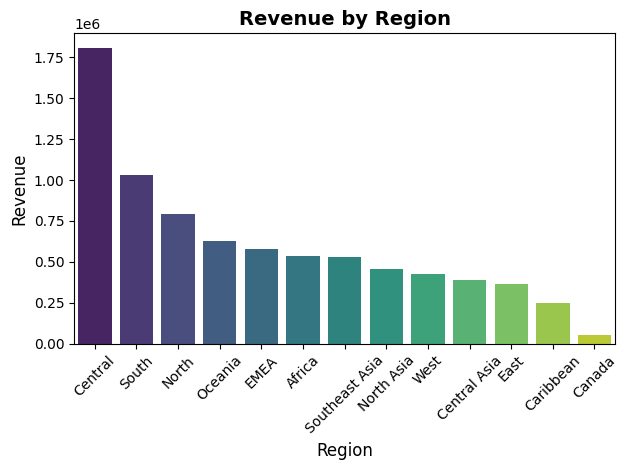

In [69]:
sns.barplot(data=region_sales,
            x='region', 
            y='revenue',
            palette='viridis',
            hue='region'
            )
plt.title("Revenue by Region", fontsize=14, weight='bold')
plt.xlabel("Region", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

result: APAC has the highest sales/
matter: This means the business performs best in this region/
suggest action: Focus more marketing and expansion in APAC

2.Monthly Revenue Trend

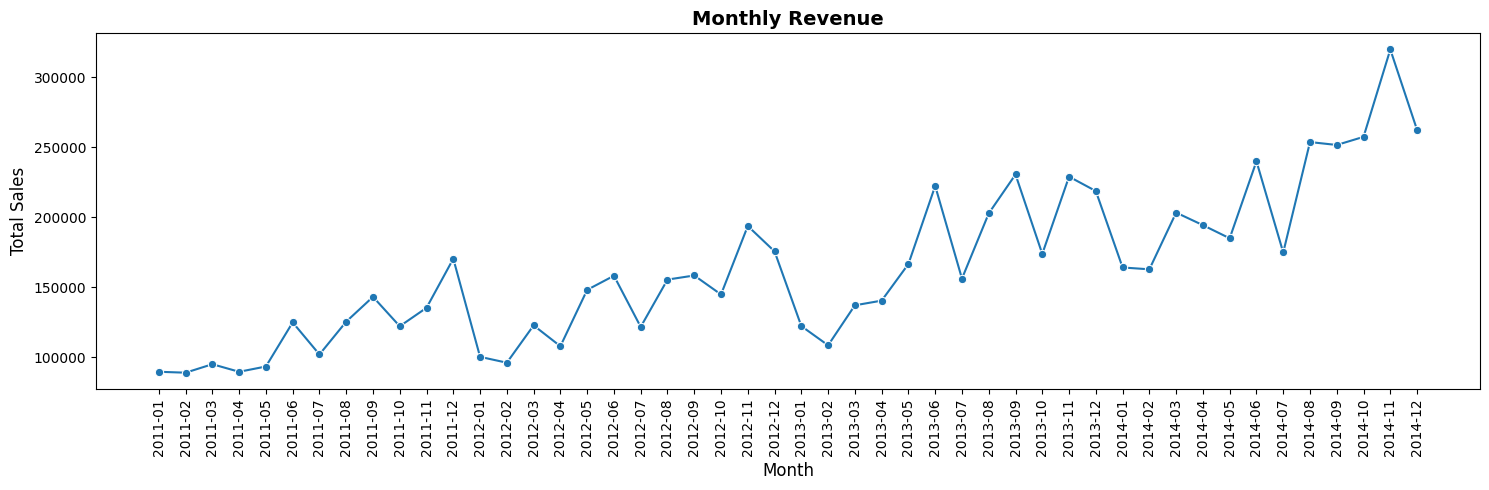

In [68]:
plt.figure(figsize=(15,5))
sns.lineplot(data=monthly_revenue,
             x='month',
             y='total_sales',
                marker='o',
             )
plt.title("Monthly Revenue", fontsize=14, weight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales", fontsize=12) 
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


result:Sales change over time with some higher months/
matter:This shows demand is not stable/
suggest action:The business can plan promotions during low months

3.Top 10 Customers

C:\Users\Mounaipconfig\AppData\Local\Temp\ipykernel_8692\3576210994.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_customers,


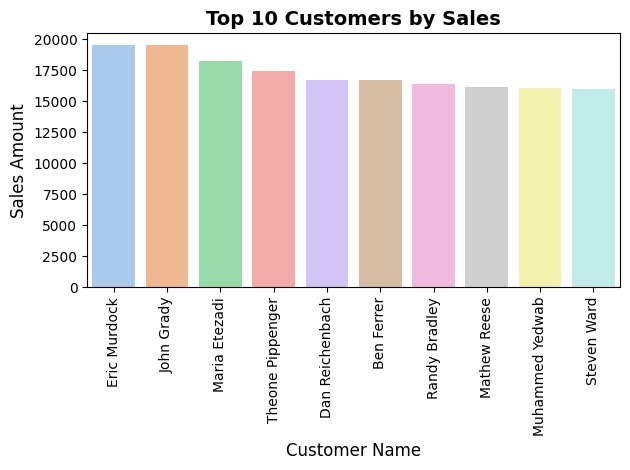

In [65]:
sns.barplot(data=top_customers,
            x='customer_name',
            y='Sales_amount',
            palette='pastel',)
plt.title("Top 10 Customers by Sales", fontsize=14, weight='bold')
plt.xlabel("Customer Name", fontsize=12)
plt.ylabel("Sales Amount", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

 result:A small number of customers generate most of the revenue/
The business should retain them using loyalty programs and personalized offers

In [ ]:
merge_sales_profits = pd.merge(category_sales, category_profits, on='category')
merge_sales_profits

,category,total_sales,total_profits
0,Office Supplies,2790258.0,518473.83430
1,Technology,2638265.0,663778.73318
2,Furniture,2406605.0,286782.25380


In [73]:
merge_sales_profits['profit_margin'] = merge_sales_profits['total_profits'] / merge_sales_profits['total_sales']
merge_sales_profits

,category,total_sales,total_profits,profit_margin
1,Technology,2638265.0,663778.73318,0.251597
0,Office Supplies,2790258.0,518473.83430,0.185816
2,Furniture,2406605.0,286782.25380,0.119165


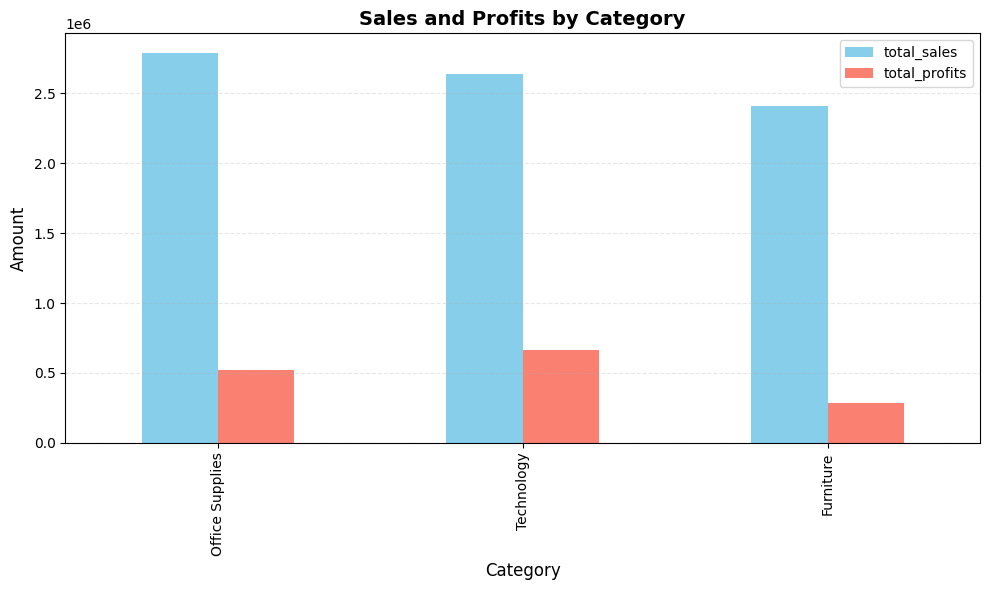

In [64]:
merge_sales_profits.set_index('category')[['total_sales','total_profits']].plot(kind='bar',
                                                                        figsize=(10,6),
                                                                         color=['skyblue', 'salmon'])
plt.title("Sales and Profits by Category", fontsize=14, weight='bold')
plt.xlabel("Category", fontsize=12)
plt.ylabel("Amount", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


result:Sales and profit do not follow the same pattern/
matter:1.Some categories generate high sales but low profit
2.This indicates inefficiency or high costs/
suggest action:The business should focus on improving profit margins, not just increasing sales.

## showing mismatch  between sales and profit clearly

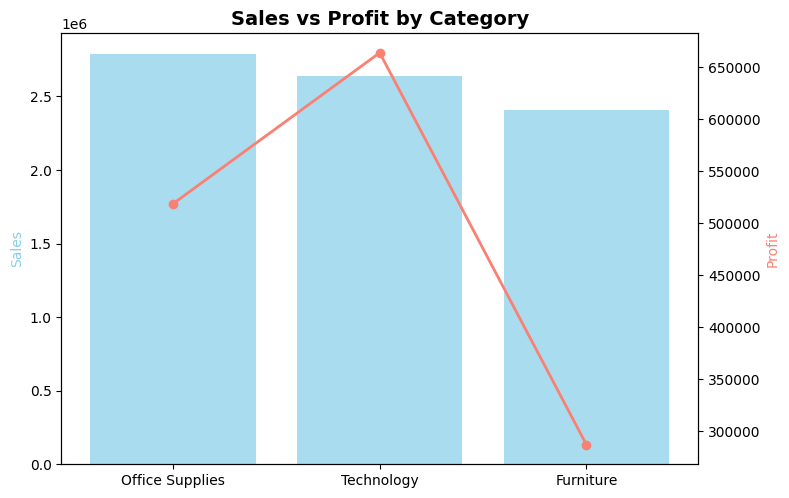

In [63]:
fig, ax1 = plt.subplots(figsize=(8,5))

# Sales
ax1.bar(
    merge_sales_profits['category'],
    merge_sales_profits['total_sales'],
    color='skyblue',
    alpha=0.7
)
ax1.set_ylabel('Sales', color='skyblue')

# Profit
ax2 = ax1.twinx()
ax2.plot(
    merge_sales_profits['category'],
    merge_sales_profits['total_profits'],
    color='salmon',
    marker='o',
    linewidth=2
)
ax2.set_ylabel('Profit', color='salmon')
plt.tight_layout()

plt.title("Sales vs Profit by Category", fontsize=14, weight='bold')
plt.show()